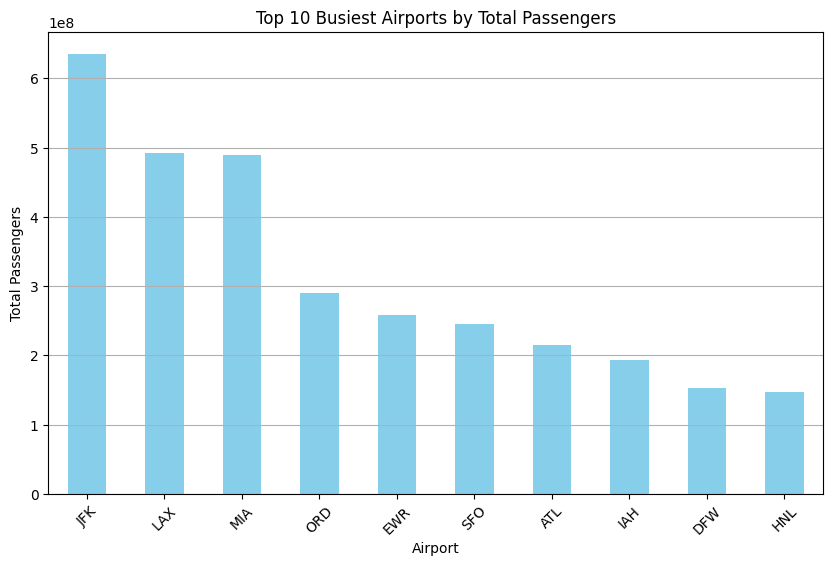

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_excel('../Dataset/merged_international_report.xlsx')

# Group by U.S. gateway and sum passengers
busiest_airports = data.groupby('usg_apt')['Total_Passengers'].sum().sort_values(ascending=False).head(10)

# Plot bar chart
plt.figure(figsize=(10, 6))
busiest_airports.plot(kind='bar', color='skyblue')
plt.title('Top 10 Busiest Airports by Total Passengers')
plt.xlabel('Airport')
plt.ylabel('Total Passengers')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


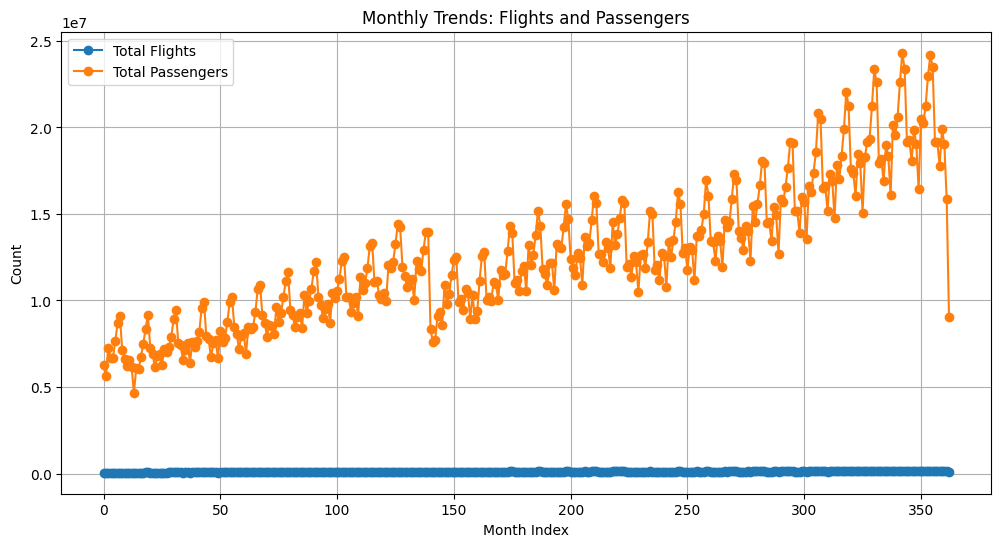

In [7]:
# Group by year and month
monthly_trends = data.groupby(['Year', 'Month'])[['Total_Flights', 'Total_Passengers']].sum().reset_index()

# Plot line chart
plt.figure(figsize=(12, 6))
plt.plot(monthly_trends['Total_Flights'], label='Total Flights', marker='o')
plt.plot(monthly_trends['Total_Passengers'], label='Total Passengers', marker='o')
plt.title('Monthly Trends: Flights and Passengers')
plt.xlabel('Month Index')
plt.ylabel('Count')
plt.legend()
plt.grid()
plt.show()


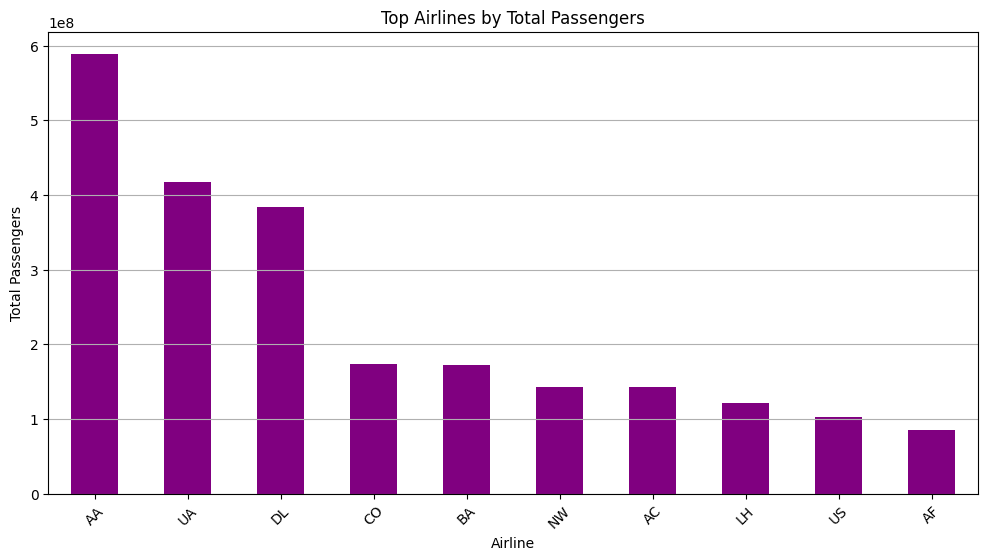

In [8]:
# Group by airline and sum passengers
airline_passengers = data.groupby('carrier')['Total_Passengers'].sum().sort_values(ascending=False).head(10)

# Plot stacked bar
airline_passengers.plot(kind='bar', stacked=True, figsize=(12, 6), color='purple')
plt.title('Top Airlines by Total Passengers')
plt.xlabel('Airline')
plt.ylabel('Total Passengers')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


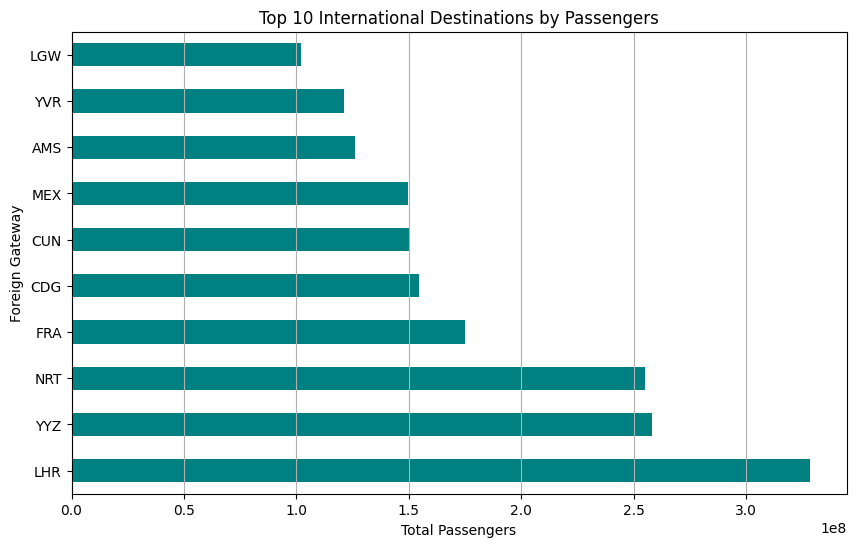

In [9]:
# Group by foreign gateway and sum passengers
foreign_destinations = data.groupby('fg_apt')['Total_Passengers'].sum().sort_values(ascending=False).head(10)

# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
foreign_destinations.plot(kind='barh', color='teal')
plt.title('Top 10 International Destinations by Passengers')
plt.xlabel('Total Passengers')
plt.ylabel('Foreign Gateway')
plt.grid(axis='x')
plt.show()


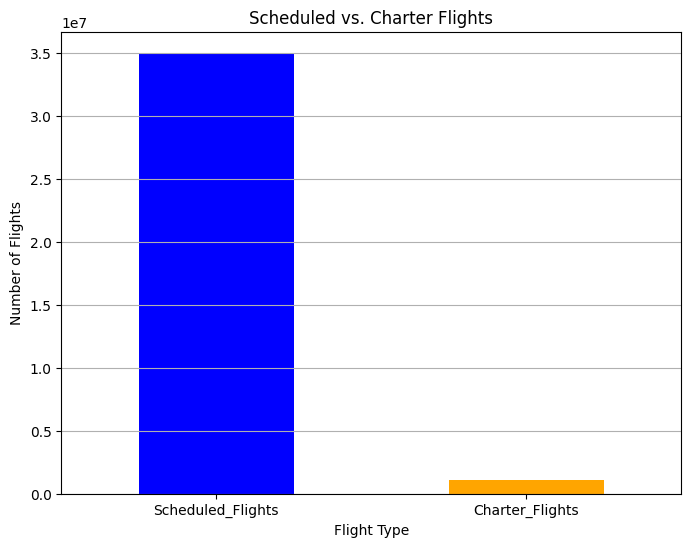

In [10]:
# Aggregate data
flight_types = data[['Scheduled_Flights', 'Charter_Flights']].sum()

# Plot grouped bar chart
flight_types.plot(kind='bar', figsize=(8, 6), color=['blue', 'orange'])
plt.title('Scheduled vs. Charter Flights')
plt.xlabel('Flight Type')
plt.ylabel('Number of Flights')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()


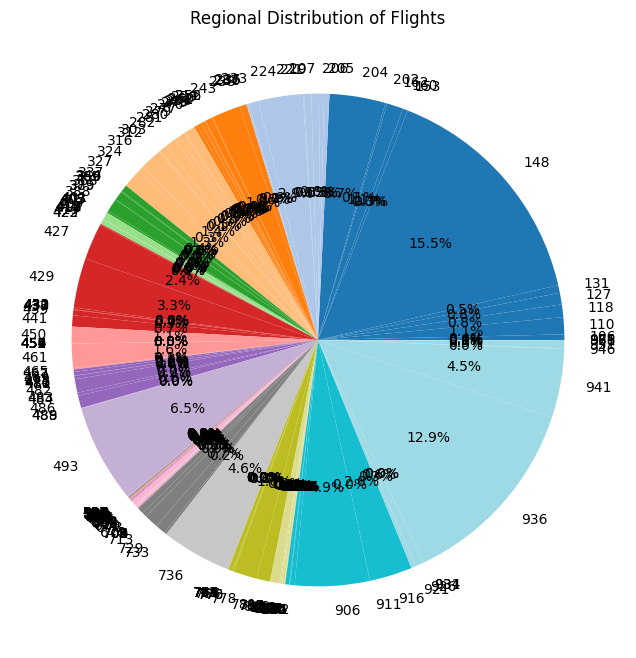

In [11]:
# Group by world area code (foreign gateway)
regional_distribution = data.groupby('fg_wac')['Total_Flights'].sum()

# Plot pie chart
regional_distribution.plot(kind='pie', autopct='%1.1f%%', figsize=(8, 8), cmap='tab20')
plt.title('Regional Distribution of Flights')
plt.ylabel('')
plt.show()


In [12]:
import plotly.express as px

# Prepare data for visualization
geo_data = data[['usg_apt', 'fg_apt', 'Total_Passengers']].groupby(['usg_apt', 'fg_apt']).sum().reset_index()

# Plot map
fig = px.scatter_geo(geo_data, locations='usg_apt', locationmode='USA-states', size='Total_Passengers',
                     hover_name='fg_apt', title='Flight Connections by Total Passengers')
fig.show()


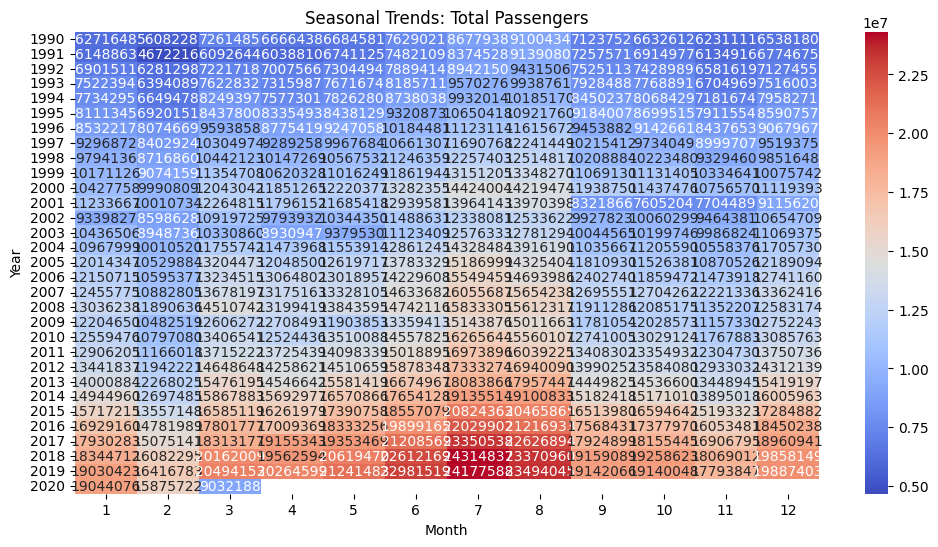

In [13]:
import seaborn as sns

# Pivot data for heatmap
seasonal_trends = data.pivot_table(values='Total_Passengers', index='Year', columns='Month', aggfunc='sum')

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(seasonal_trends, cmap='coolwarm', annot=True, fmt='.0f')
plt.title('Seasonal Trends: Total Passengers')
plt.xlabel('Month')
plt.ylabel('Year')
plt.show()


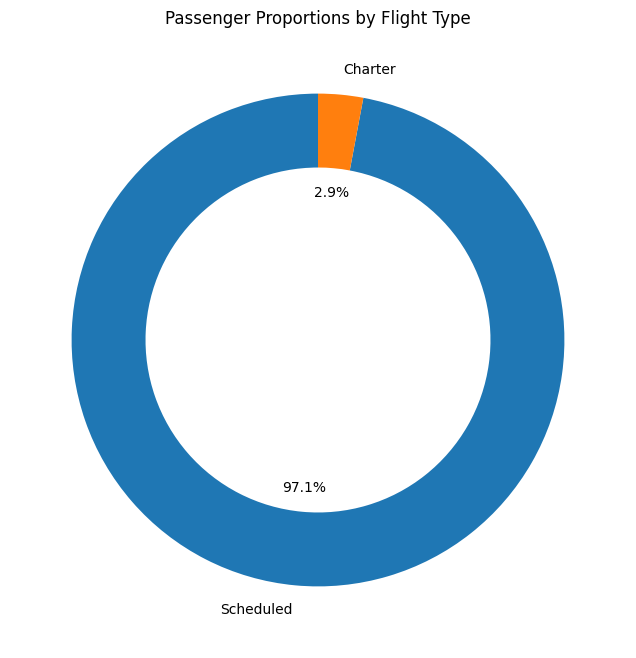

In [14]:
# Aggregate passenger data
passenger_data = data[['Scheduled_Passengers', 'Charter_Passengers']].sum()

# Plot donut chart
plt.figure(figsize=(8, 8))
plt.pie(passenger_data, labels=['Scheduled', 'Charter'], autopct='%1.1f%%', startangle=90, wedgeprops=dict(width=0.3))
plt.title('Passenger Proportions by Flight Type')
plt.show()


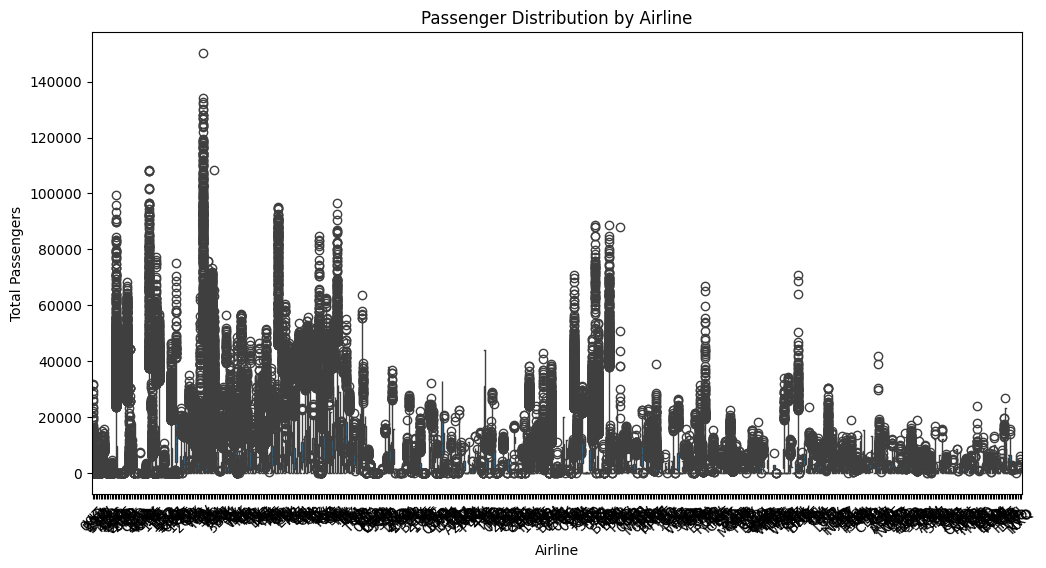

In [15]:
import seaborn as sns

# Plot boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='carrier', y='Total_Passengers', data=data)
plt.title('Passenger Distribution by Airline')
plt.xlabel('Airline')
plt.ylabel('Total Passengers')
plt.xticks(rotation=45)
plt.show()


In [19]:
import pandas as pd

# Load flight dataset
file_path = '../Dataset/merged_international_report.xlsx'
data = pd.read_excel(file_path)

# Filter data to ensure validity
data = data[data['Total_Flights'] > 0].dropna(subset=['Total_Flights'])

# Group data by airline and year to aggregate flights
airlines_flights_per_year = data.groupby(['Year', 'carrier'])['Total_Flights'].sum().reset_index()

# Sort flights for each year and pick the top 20 airlines
top_airlines_per_year = (
    airlines_flights_per_year.groupby('Year')
    .apply(lambda group: group.nlargest(20, 'Total_Flights'))
    .reset_index(drop=True)
)

# Save the results to an Excel file
output_file = 'top_20_airlines_per_year1.xlsx'
with pd.ExcelWriter(output_file, engine='xlsxwriter') as writer:
    for year in top_airlines_per_year['Year'].unique():
        year_data = top_airlines_per_year[top_airlines_per_year['Year'] == year]
        year_data[['carrier', 'Total_Flights']].to_excel(writer, sheet_name='flights', index=False, startrow=1, startcol=1)

print(f"Top 20 airlines per year saved to {output_file}")


Top 20 airlines per year saved to top_20_airlines_per_year1.xlsx


C:\Users\Soroush\AppData\Local\Temp\ipykernel_26512\2205035529.py:16: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

